In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_curve, roc_auc_score

KAGGLE:This is the classic marketing bank dataset uploaded originally in the UCI Machine Learning Repository. The dataset gives you information about a marketing campaign of a financial institution in which you will have to analyze in order to find ways to look for future strategies in order to improve future marketing campaigns for the bank.

In [29]:
from sklearn.model_selection import train_test_split

data = pd.read_csv("../data/bank.csv")

features = data.columns[:-1] # reszta
target_col = data.columns[-1] # deposit

data[target_col] = data[target_col].map({'yes': 1, 'no': 0})

X = data.drop(target_col, axis=1)
y = data[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2137)

In [30]:
numerical_features = X_train.select_dtypes(include=np.number).columns
categorical_features = X_train.select_dtypes(exclude=np.number).columns

print(f"Numeryczne: {list(numerical_features)}")
print(f"Kategoryczne: {list(categorical_features)}")

Numeryczne: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Kategoryczne: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [31]:

scaler = MinMaxScaler()
scaler.fit(X_train[numerical_features])

# aby nie nadpisać danych
X_train_proc = X_train.copy()
X_test_proc = X_test.copy()

X_train_proc[numerical_features] = scaler.transform(X_train[numerical_features])
X_test_proc[numerical_features] = scaler.transform(X_test[numerical_features])

# one-hot / get_dummies
X_train_proc = pd.get_dummies(X_train_proc, columns=categorical_features, drop_first=True)
X_test_proc = pd.get_dummies(X_test_proc, columns=categorical_features, drop_first=True)

# dopasowanie kolumn, i fill
train_cols = X_train_proc.columns
X_test_proc = X_test_proc.reindex(columns=train_cols, fill_value=0)

In [32]:
print(f"Liczba cech po przetworzeniu danych: {len(train_cols)}")

Liczba cech po przetworzeniu danych: 42


In [33]:
model = LogisticRegression(max_iter=1000, random_state=2137)
model.fit(X_train_proc, y_train)

y_probs = model.predict_proba(X_test_proc)[:, 1] # pstwa dla deposit=yes

In [34]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

thresholds = [0.1, 0.25, 0.5, 0.75, 0.9]
results = []

for t in thresholds:
    y_pred_cnt = (y_probs >= t).astype(int)
    # zero_division=0 zapobiega błędom, gdyby nie było żadnych predykcji.
    accuracy = accuracy_score(y_test, y_pred_cnt)
    precision = precision_score(y_test, y_pred_cnt, pos_label=1, zero_division=0)
    recall = recall_score(y_test, y_pred_cnt, pos_label=1, zero_division=0)
    f1 = f1_score(y_test, y_pred_cnt, pos_label=1, zero_division=0)

    results.append({
        'Threshold': t,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-score': f1
    })

df_results = pd.DataFrame(results)
df_results = df_results.set_index('Threshold')

display(df_results)

,Accuracy,Precision,Recall,F1-score
Threshold,,,,
0.10,0.594268,0.530877,0.998049,0.693089
0.25,0.778325,0.683518,0.962927,0.799514
0.50,0.821764,0.814443,0.792195,0.803165
0.75,0.747873,0.871383,0.528780,0.658166
0.90,0.661890,0.897059,0.297561,0.446886


Obserwacje:
Zmiana progu silnie wpływa na Recall i Precision dla klasy 'yes'.

Niski próg (0.1) łapie wielu klientów 'yes' (wysoka czułość), ale kosztem wielu pomyłek (niska precyzja).

Wysoki próg (0.9) jest bardzo 'pewny' swoich predykcji 'yes' (wysoka precyzja), ale pomija większość z nich (niska czułość).

Pole pod krzywą (AUROC) - ŚREDNIA!: 0.9027 (Im więcej, tym lepiej)


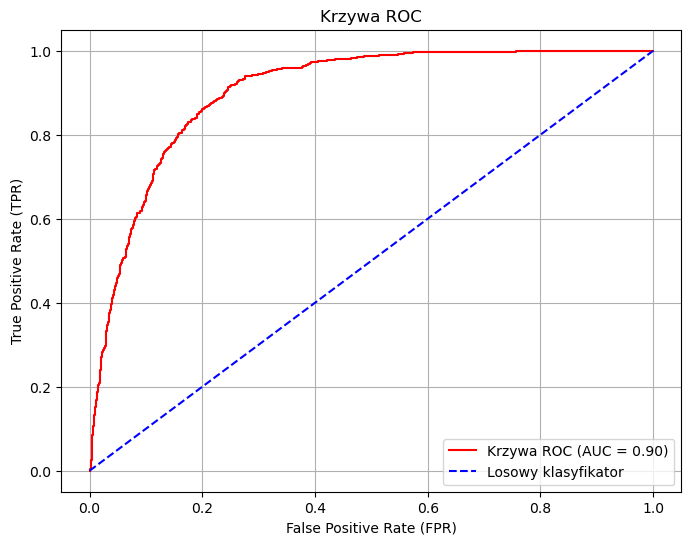

In [35]:
fpr, tpr, thresholds_roc = roc_curve(y_test, y_probs) # lista punktów (fpr, tpr)
auc = roc_auc_score(y_test, y_probs)

print(f"Pole pod krzywą (AUROC) - ŚREDNIA!: {auc:.4f} (Im więcej, tym lepiej)")

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='red', label=f'Krzywa ROC (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='blue', linestyle='--', label='Losowy klasyfikator')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Krzywa ROC')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

Wygląda nie najgorzej

In [36]:
cost_fp = 10
cost_fn = 3

P = y_test.sum() # prawdziwe yes
N = len(y_test) - P # prawdziwe no

total_costs = (fpr * N * cost_fp) + ((1 - tpr) * P * cost_fn) # to jest lista jak coś

optimal_idx = np.argmin(total_costs)
optimal_threshold = thresholds_roc[optimal_idx]
min_cost = total_costs[optimal_idx]

print(f"Liczba NO: {N}, Liczba YES : {P}")
print(f"Próg minimalizujący koszt: {optimal_threshold:.4f}")
print(f"Koszt przy tym progu: {min_cost:.2f}")

Liczba NO: 1208, Liczba YES : 1025
Próg minimalizujący koszt: 0.7092
Koszt przy tym progu: 2195.00


MODEL NA DWÓCH NAJLEPSZYCH PREDYKTORACH

In [37]:
print(model.coef_.shape)

coefs = pd.Series(model.coef_[0], index=X_train_proc.columns)

print(coefs)

(1, 42)
age                     0.005331
balance                 1.398758
day                     0.048206
duration               17.151566
campaign               -2.622141
pdays                  -0.022431
previous                0.172507
job_blue-collar        -0.192701
job_entrepreneur       -0.303573
job_housemaid          -0.416597
job_management         -0.240161
job_retired             0.363003
job_self-employed      -0.357542
job_services           -0.226676
job_student             0.600031
job_technician         -0.129034
job_unemployed         -0.093830
job_unknown            -0.325452
marital_married        -0.155821
marital_single          0.107124
education_secondary     0.144851
education_tertiary      0.398796
education_unknown       0.287708
default_yes            -0.040302
housing_yes            -0.694537
loan_yes               -0.454019
contact_telephone      -0.125160
contact_unknown        -1.397995
month_aug              -0.803362
month_dec               1.158254
mo

In [40]:
# Wybieramy 2 najlepsze cechy, ale TYLKO SPOŚRÓD NUMERYCZNYCH, aby móc narysować sensowny wykres
# wszystko jest znormalizowane więc jak coś ma największe CO DO MODUŁU wsp to powinno być najważniejsze
best_numerical_features = coefs[numerical_features].abs().nlargest(2).index.tolist()
print(f"Wybrane 2 najlepsze predyktory: {best_numerical_features}")

X_train_2 = X_train[best_numerical_features]
X_test_2 = X_test[best_numerical_features]

# budujemy nowy model, więc znowu to przeskalujmy wszystko żeby było porządnie, tak jak zwykle
scaler_2 = MinMaxScaler()
scaler_2.fit(X_train_2)

X_train_2_proc = scaler_2.transform(X_train_2)
X_test_2_proc = scaler_2.transform(X_test_2)

model_2 = LogisticRegression()
model_2.fit(X_train_2_proc, y_train)

Wybrane 2 najlepsze predyktory: ['duration', 'campaign']


LogisticRegression()

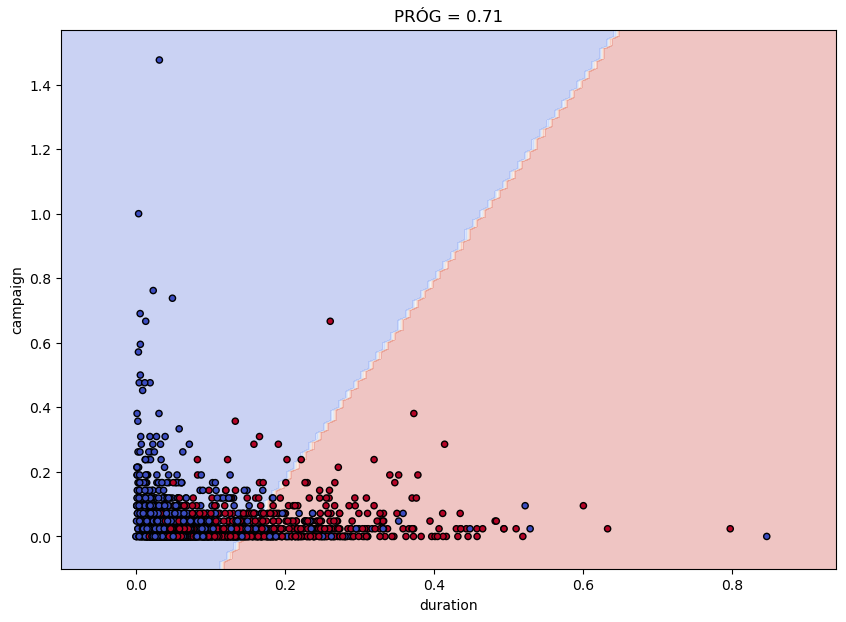

In [ ]:
# mesh grid
x_min, x_max = X_test_2_proc[:, 0].min() - 0.1, X_test_2_proc[:, 0].max() + 0.1
y_min, y_max = X_test_2_proc[:, 1].min() - 0.1, X_test_2_proc[:, 1].max() + 0.1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

# estymuje prawdopodobieństwa dla każdego punktu w powyższej siatace
probs = model_2.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]

pred = (probs >= optimal_threshold).astype(int)
Z = pred.reshape(xx.shape)

# rysowanie
plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_test_2_proc[:, 0], X_test_2_proc[:, 1], c=y_test, s=20, edgecolor='k', cmap='coolwarm') 
# c mówi na podstawie czego koloruje, s to powierzchnia kropki, cmap mapuje kolory, edgecolor ustawia brzeg kropoki na czarny
plt.title(f'PRÓG = {optimal_threshold:.2f}')
plt.xlabel(f'{best_numerical_features[0]}')
plt.ylabel(f'{best_numerical_features[1]}')
plt.show()

Regresja logistyczna to model liniowy, więc naturalnie ta granica wychodzi jako prosta

Model na postawie tych dwóch paremtrów i cech (roboczo x1,x2,w1,w2) wyznacza tam takie paremetry aby:

$\sigma(w1 \cdot x1 + w2 \cdot x2) = \text{threshold}$

czyli

$w1 \cdot x1 + w2 \cdot x2 = \sigma^{-1}(\text{threshold})$

a to jest właśnie równanie prostej, wiemy też że skoro dla wek A i B na tej prostej
$⟨W,A⟩ = ⟨W,B⟩ = c$

to $⟨W,A -B⟩ =0$ czyli ten wektor jest PROTOPADŁY do prostej,

dokładniej wskasuję on w kierunku wzrostu funkcji $⟨W,X⟩$ CZYLI JAK CHCEMY MAKSYMALIZOWAĆ PSTWO TO MUSIMY ISC W TYM KIERUNKU (my tylko ustalamy poziomice)